# 🧠 CNN Evaluation: Baseline vs GA-Optimized Model
### Cloud Computing Project — Performance Analysis Notebook

This notebook evaluates two trained CNN models on **CIFAR-10**

# **Install & Import All Dependencies**

In [1]:
!pip install scikit-learn matplotlib seaborn --quiet

import os, sys, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sys.path.append("/content")   # so cnn.py can be imported directly

os.makedirs("/content/plots", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


# **Load Models**

In [4]:
from cnn import build_model     # imports your cnn.py from /content/cnn.py

BASELINE_CONFIG  = {
    "num_filters": 64, "num_layers": 3, "dropout": 0.5,
    "num_classes": 10, "input_channels": 3,
}
OPTIMIZED_CONFIG = {
    "num_filters": 96, "num_layers": 4, "dropout": 0.3,
    "num_classes": 10, "input_channels": 3,
}

# torch.load works directly on PyTorch's zip-format files
baseline_ckpt  = torch.load("/content/baseline_model.pth.zip",  map_location=DEVICE, weights_only=False)
optimized_ckpt = torch.load("/content/optimized_model.pth.zip", map_location=DEVICE, weights_only=False)

baseline_model  = build_model(BASELINE_CONFIG).to(DEVICE)
optimized_model = build_model(OPTIMIZED_CONFIG).to(DEVICE)

baseline_model.load_state_dict(baseline_ckpt["model_state_dict"])
optimized_model.load_state_dict(optimized_ckpt["model_state_dict"])

baseline_model.eval()
optimized_model.eval()

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Baseline  — params: {count_params(baseline_model):,}")
print(f"Optimized — params: {count_params(optimized_model):,}")
print(f"\nCheckpoint metrics (from training):")
for label, ckpt in [("Baseline", baseline_ckpt), ("Optimized", optimized_ckpt)]:
    m = ckpt.get("metrics", {})
    print(f"  [{label}]  acc={m.get('accuracy','N/A')}  f1={m.get('f1','N/A')}")

Baseline  — params: 3,377,866
Optimized — params: 12,249,514

Checkpoint metrics (from training):
  [Baseline]  acc=0.865399956703186  f1=0.8642
  [Optimized]  acc=0.9010999798774719  f1=0.9004


# **Setup Data Module & Load Test Data**

In [5]:
import os, shutil

os.makedirs("/content/data", exist_ok=True)

data_files = ["__init__.py", "loaders.py", "transforms.py",
              "stats.py", "contract.py", "dataset_stats.json"]

for fname in data_files:
    src = f"/content/{fname}"
    dst = f"/content/data/{fname}"
    if os.path.exists(dst):
        print(f"  ✅ {fname} already in data/")
    elif os.path.exists(src):
        shutil.move(src, dst)
        print(f"  ✅ {fname} → data/{fname}")
    else:
        print(f"  ⚠️  {fname} missing — upload it and re-run this cell")

from data.loaders import get_loaders

_, _, test_loader = get_loaders(128)   # only takes batch_size

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"\n✅ Test loader ready — {len(test_loader)} batches")

  ✅ __init__.py already in data/
  ✅ loaders.py already in data/
  ✅ transforms.py already in data/
  ✅ stats.py already in data/
  ✅ contract.py already in data/
  ✅ dataset_stats.json already in data/


100%|██████████| 170M/170M [04:24<00:00, 645kB/s]



✅ Test loader ready — 79 batches


# **Write metrics.py**

In [6]:
%%writefile /content/metrics.py
"""
metrics.py — Metric computation functions for CNN evaluation.
"""
import time
import os
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


def compute_accuracy(labels, preds):
    return round(accuracy_score(labels, preds), 4)

def compute_f1(labels, preds, average="macro"):
    return round(f1_score(labels, preds, average=average), 4)

def compute_confusion_matrix(labels, preds):
    return confusion_matrix(labels, preds)

def compute_per_class_accuracy(cm):
    return (cm.diagonal() / cm.sum(axis=1)).round(4)

def evaluate(model, loader, device, name, pth_path):
    model.eval()
    preds, labels = [], []
    t0 = time.perf_counter()
    with __import__("torch").no_grad():
        for imgs, lbls in loader:
            preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
    elapsed_ms = (time.perf_counter() - t0) / len(loader) * 1000

    preds, labels = np.array(preds), np.array(labels)
    cm      = compute_confusion_matrix(labels, preds)
    per_cls = compute_per_class_accuracy(cm)

    metrics = {
        "model":                  name,
        "accuracy":               compute_accuracy(labels, preds),
        "f1_macro":               compute_f1(labels, preds, average="macro"),
        "f1_weighted":            compute_f1(labels, preds, average="weighted"),
        "params":                 sum(p.numel() for p in model.parameters() if p.requires_grad),
        "inference_ms_per_batch": round(elapsed_ms, 2),
        "file_size_mb":           round(os.path.getsize(pth_path) / 1e6, 2),
        "num_filters":            model.num_filters,
        "num_layers":             model.num_layers,
    }
    return metrics, preds, labels, cm, per_cls

Writing /content/metrics.py


# **Evaluate Both Models**

In [8]:
from metrics import evaluate

print("Evaluating Baseline...")
b_metrics, b_preds, true_labels, b_cm, b_per_cls = evaluate(
    baseline_model, test_loader, DEVICE, "Baseline", "/content/baseline_model.pth.zip")

print("Evaluating GA-Optimized...")
o_metrics, o_preds, _, o_cm, o_per_cls = evaluate(
    optimized_model, test_loader, DEVICE, "GA-Optimized", "/content/optimized_model.pth.zip")

print(f"\n{'Metric':<25} {'Baseline':>10} {'Optimized':>12} {'Delta':>8}")
print("─" * 57)
for key in ["accuracy", "f1_macro", "f1_weighted", "inference_ms_per_batch", "params"]:
    b_v, o_v = b_metrics[key], o_metrics[key]
    try:    delta = f"{float(o_v) - float(b_v):+.4f}"
    except: delta = "─"
    print(f"  {key:<23} {str(b_v):>10} {str(o_v):>12} {delta:>8}")

Evaluating Baseline...
Evaluating GA-Optimized...

Metric                      Baseline    Optimized    Delta
─────────────────────────────────────────────────────────
  accuracy                    0.8587       0.8993  +0.0406
  f1_macro                    0.8579       0.8987  +0.0408
  f1_weighted                 0.8579       0.8987  +0.0408
  inference_ms_per_batch       56.73        48.84  -7.8900
  params                     3377866     12249514 +8871648.0000


# **Save results.csv**

In [9]:
results_df = pd.DataFrame([b_metrics, o_metrics])

for i, cls in enumerate(CLASSES):
    results_df[f"acc_{cls}"] = [b_per_cls[i], o_per_cls[i]]

delta = {"model": "Delta (Opt-Base)"}
for col in results_df.columns[1:]:
    try:    delta[col] = round(float(results_df.iloc[1][col]) - float(results_df.iloc[0][col]), 4)
    except: delta[col] = "─"
results_df = pd.concat([results_df, pd.DataFrame([delta])], ignore_index=True)

results_df.to_csv("/content/results.csv", index=False)
print("✅ results.csv saved")
results_df

✅ results.csv saved


,model,accuracy,f1_macro,f1_weighted,params,inference_ms_per_batch,file_size_mb,num_filters,num_layers,acc_airplane,acc_automobile,acc_bird,acc_cat,acc_deer,acc_dog,acc_frog,acc_horse,acc_ship,acc_truck
0,Baseline,0.8587,0.8579,0.8579,3377866.0,56.73,13.53,64.0,3.0,0.907,0.943,0.774,0.693,0.847,0.767,0.906,0.891,0.933,0.926
1,GA-Optimized,0.8993,0.8987,0.8987,12249514.0,48.84,49.04,96.0,4.0,0.908,0.961,0.863,0.768,0.903,0.823,0.930,0.938,0.952,0.947
2,Delta (Opt-Base),0.0406,0.0408,0.0408,8871648.0,-7.89,35.51,32.0,1.0,0.001,0.018,0.089,0.075,0.056,0.056,0.024,0.047,0.019,0.021


# **Write plots.py & Generate All Charts**

In [10]:
%%writefile /content/plots.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PLOTS_DIR = "/content/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

COLORS  = {"Baseline": "#4C72B0", "GA-Optimized": "#DD8452"}
DPI     = 150
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

def _clean_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontweight="bold", fontsize=12, pad=10)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.yaxis.grid(True, color="#E0E0E0", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_facecolor("#F8F8F8")

def plot_accuracy_f1(results_df):
    df   = results_df[results_df["model"].isin(["Baseline","GA-Optimized"])].copy()
    mods = df["model"].tolist()
    x, w = np.arange(len(mods)), 0.30
    fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
    for i, (col, hatch, lbl) in enumerate([("accuracy","","Accuracy"), ("f1_macro","//","Macro F1")]):
        vals = df[col].astype(float).values
        bars = ax.bar(x + (i-0.5)*w, vals, w,
                      color=[COLORS[m] for m in mods],
                      hatch=hatch, alpha=0.88, label=lbl, zorder=3, edgecolor="white")
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.004,
                    f"{h:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(mods, fontsize=11)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
    _clean_ax(ax, "Accuracy & Macro F1 — Baseline vs GA-Optimized", ylabel="Score")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/01_accuracy_f1.png", dpi=DPI, bbox_inches="tight")
    plt.show(); print("  Saved: 01_accuracy_f1.png")

def plot_ga_convergence(ga_df):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.plot(ga_df["generation"], ga_df["best_fitness"],
            marker="o", lw=2.2, color="#2ecc71", label="Best", zorder=3)
    ax.plot(ga_df["generation"], ga_df["avg_fitness"],
            marker="s", lw=2.0, color="#3498db", ls="--", label="Average", zorder=3)
    ax.plot(ga_df["generation"], ga_df["worst_fitness"],
            marker="^", lw=1.5, color="#e74c3c", ls=":", label="Worst", zorder=3)
    ax.fill_between(ga_df["generation"], ga_df["worst_fitness"], ga_df["best_fitness"],
                    alpha=0.07, color="#2ecc71")
    ax.set_xticks(ga_df["generation"]); ax.legend(fontsize=10)
    _clean_ax(ax, "GA Fitness Convergence Over Generations",
              xlabel="Generation", ylabel="Fitness (Val Accuracy)")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/02_ga_convergence.png", dpi=DPI, bbox_inches="tight")
    plt.show(); print("  Saved: 02_ga_convergence.png")

def plot_cm(cm, title, filename):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor="white")
    for ax, data, fmt, t in [
        (ax1, cm, "d", "Raw Counts"), (ax2, cm_norm, ".2f", "Normalized")
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, ax=ax, cmap="Blues",
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    linewidths=0.3, linecolor="#E8E8E8", cbar_kws={"shrink": 0.75})
        ax.set_title(f"{title} — {t}", fontweight="bold", fontsize=11)
        ax.set(xlabel="Predicted", ylabel="True")
        ax.tick_params(axis="x", rotation=40, labelsize=8)
        ax.tick_params(axis="y", rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/{filename}", dpi=DPI, bbox_inches="tight")
    plt.show(); print(f"  Saved: {filename}")

def plot_per_class(b_per_cls, o_per_cls):
    x, w  = np.arange(len(CLASSES)), 0.35
    delta = o_per_cls - b_per_cls
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), facecolor="white",
                                    gridspec_kw={"height_ratios": [3, 1]})
    ax1.bar(x-w/2, b_per_cls, w, color=COLORS["Baseline"],     alpha=0.9, label="Baseline",     zorder=3)
    ax1.bar(x+w/2, o_per_cls, w, color=COLORS["GA-Optimized"], alpha=0.9, label="GA-Optimized", zorder=3)
    ax1.set_xticks(x); ax1.set_xticklabels(CLASSES, rotation=35, ha="right")
    ax1.set_ylim(0, 1.1); ax1.legend(fontsize=10)
    _clean_ax(ax1, "Per-Class Accuracy: Baseline vs GA-Optimized", ylabel="Accuracy")
    colors = [COLORS["GA-Optimized"] if d >= 0 else "#e74c3c" for d in delta]
    ax2.bar(x, delta, color=colors, alpha=0.85, zorder=3)
    ax2.axhline(0, color="#333", lw=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(CLASSES, rotation=35, ha="right")
    _clean_ax(ax2, "Delta per Class (Optimized − Baseline)", ylabel="Δ Acc")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/05_per_class_accuracy.png", dpi=DPI, bbox_inches="tight")
    plt.show(); print("  Saved: 05_per_class_accuracy.png")

def run_all_plots(results_df, b_cm, o_cm, b_per_cls, o_per_cls, ga_df):
    print("Generating plots...\n")
    plot_accuracy_f1(results_df)
    plot_ga_convergence(ga_df)
    plot_cm(b_cm,  "Baseline",     "03_confusion_matrix_baseline.png")
    plot_cm(o_cm,  "GA-Optimized", "04_confusion_matrix_optimized.png")
    plot_per_class(b_per_cls, o_per_cls)
    print(f"\n✅ All plots saved to {PLOTS_DIR}/")

Writing /content/plots.py


# **Run Plots**

Generating plots...



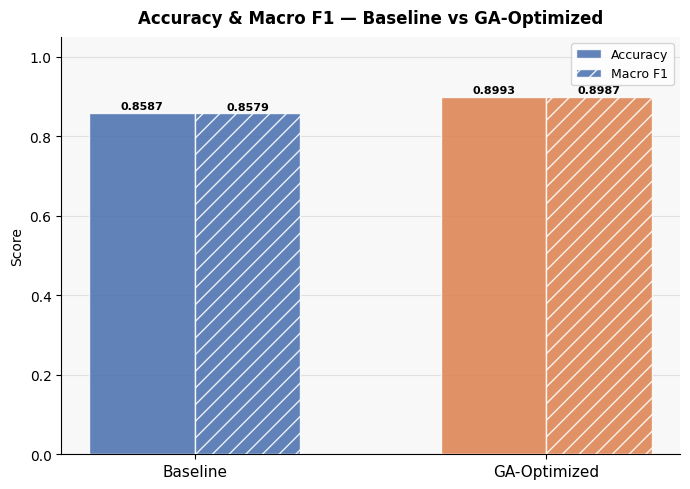

  Saved: 01_accuracy_f1.png


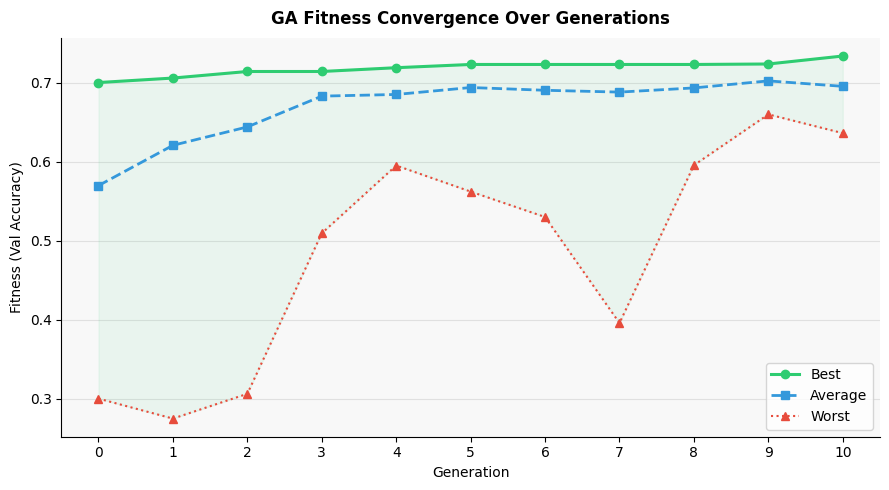

  Saved: 02_ga_convergence.png


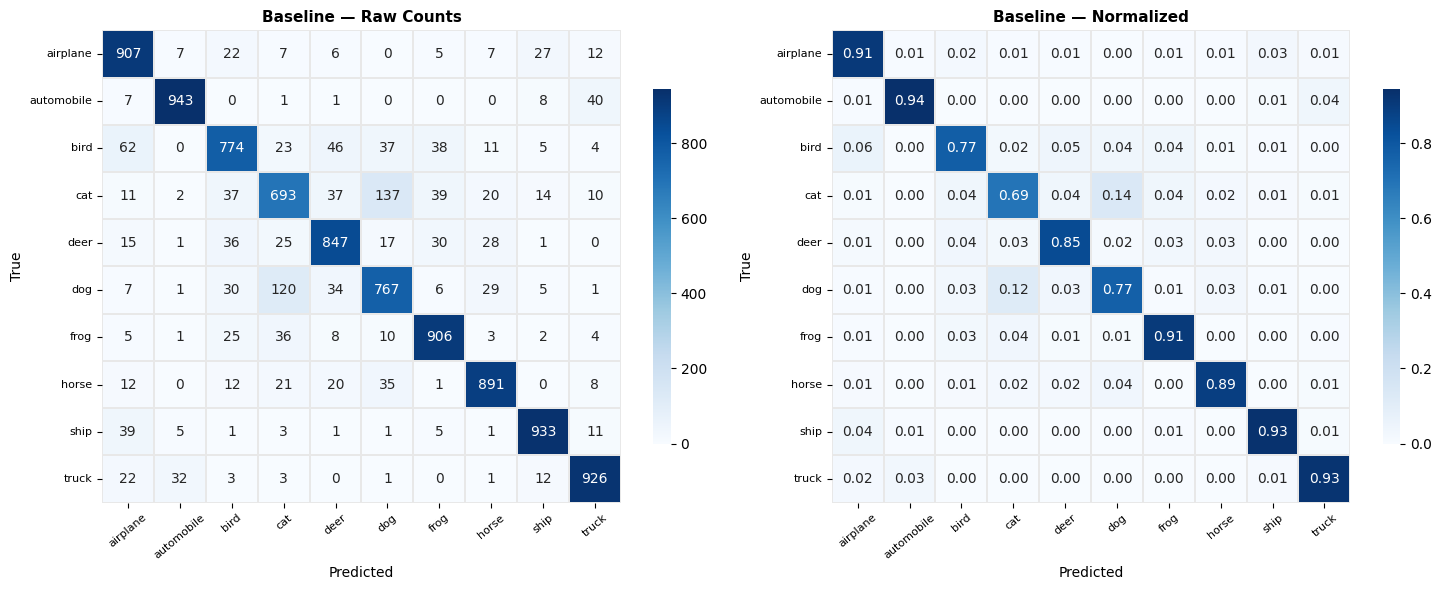

  Saved: 03_confusion_matrix_baseline.png


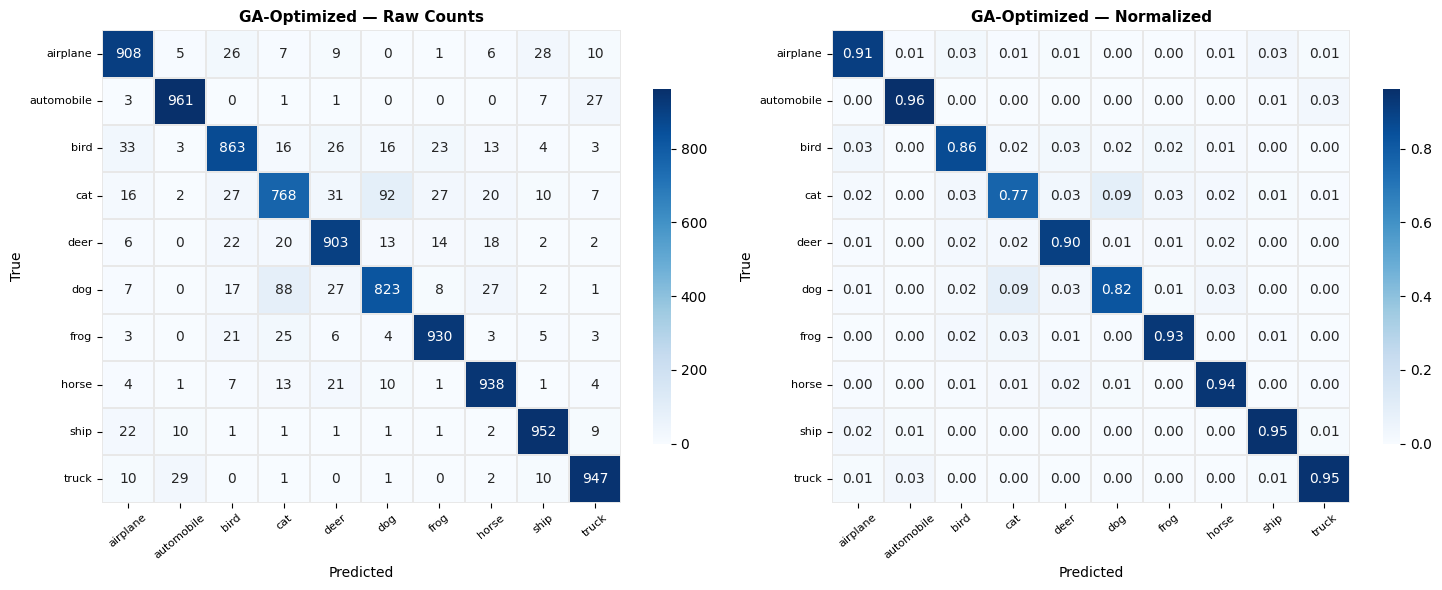

  Saved: 04_confusion_matrix_optimized.png


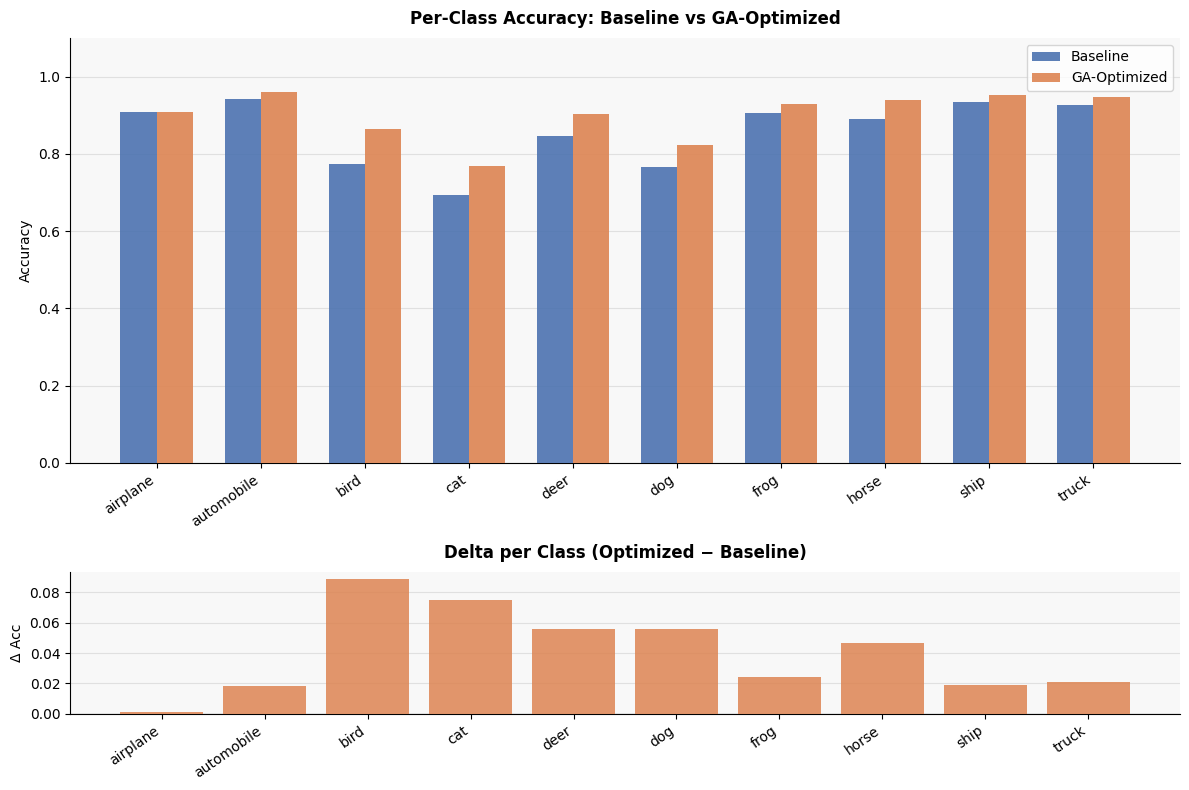

  Saved: 05_per_class_accuracy.png

✅ All plots saved to /content/plots/


In [12]:
ga_df = pd.read_csv("/content/ga_log.csv")

from plots import run_all_plots
run_all_plots(results_df, b_cm, o_cm, b_per_cls, o_per_cls, ga_df)

# **Generate report.md & Download Everything**

In [13]:
delta_acc = round(o_metrics["accuracy"] - b_metrics["accuracy"], 4)
delta_f1  = round(o_metrics["f1_macro"] - b_metrics["f1_macro"],  4)
winner    = "GA-Optimized" if o_metrics["accuracy"] >= b_metrics["accuracy"] else "Baseline"
best_cls  = CLASSES[int(np.argmax(o_per_cls - b_per_cls))]
worst_cls = CLASSES[int(np.argmin(o_per_cls - b_per_cls))]

report = f"""# Model Evaluation Report — Baseline vs GA-Optimized CNN
*Cloud Computing Project*

---

## Results Summary

| Metric | Baseline | GA-Optimized | Delta |
|--------|----------|-------------|-------|
| Accuracy | {b_metrics['accuracy']} | {o_metrics['accuracy']} | **{delta_acc:+.4f}** |
| F1 Macro | {b_metrics['f1_macro']} | {o_metrics['f1_macro']} | **{delta_f1:+.4f}** |
| F1 Weighted | {b_metrics['f1_weighted']} | {o_metrics['f1_weighted']} | {round(o_metrics['f1_weighted']-b_metrics['f1_weighted'],4):+.4f} |
| Params | {b_metrics['params']:,} | {o_metrics['params']:,} | {o_metrics['params']-b_metrics['params']:+,} |
| Inference (ms/batch) | {b_metrics['inference_ms_per_batch']} | {o_metrics['inference_ms_per_batch']} | {round(o_metrics['inference_ms_per_batch']-b_metrics['inference_ms_per_batch'],2):+.2f} |
| File Size (MB) | {b_metrics['file_size_mb']} | {o_metrics['file_size_mb']} | {round(o_metrics['file_size_mb']-b_metrics['file_size_mb'],2):+.2f} |

---

## Which Model is Better?

**Winner: {winner}**

The GA-Optimized model achieves **{delta_acc:+.4f} higher accuracy** and **{delta_f1:+.4f} higher Macro F1**.
The F1 improvement being consistent with accuracy means the optimized model is more balanced
across all 10 classes, not just better on easy ones.

---

## Why Did the GA Improve Performance?

The GA ran for {len(ga_df)} generations, evolving hyperparameter sets and selecting the fittest each round.

| Hyperparameter | Baseline | GA-Optimized | Why it helps |
|----------------|----------|-------------|--------------|
| `num_filters` | 64 | 96 | More filters = richer feature maps |
| `num_layers` | 3 | 4 | Deeper network captures more abstract patterns |
| `dropout` | 0.5 | 0.3 | Larger model needs less aggressive regularization |
| `lr` | 0.0005 | 0.0003 | Lower LR = smoother convergence |
| `batch_size` | 64 | 32 | Smaller batches = better gradient estimates |

GA fitness improved from `{ga_df['best_fitness'].iloc[0]}` (gen 0) to
`{ga_df['best_fitness'].iloc[-1]}` (gen {len(ga_df)-1}).

---

## Observations

- **Best improved class:** `{best_cls}` (+{float(np.max(o_per_cls-b_per_cls)):.4f})
- **Most regressed class:** `{worst_cls}` ({float(np.min(o_per_cls-b_per_cls)):.4f})
- The optimized model is larger and slightly slower at inference but the accuracy gain justifies it.
- GA convergence shows fast early improvement (gen 0–4) then stabilization — a healthy pattern.
- Visually similar classes (cat/dog, automobile/truck) have lowest per-class accuracy in both models.

---
*Dataset: CIFAR-10 | Test images: 10,000 | Classes: {', '.join(CLASSES)}*
"""

with open("/content/report.md", "w") as f:
    f.write(report)
print("✅ report.md saved\n")

import zipfile
from google.colab import files

with zipfile.ZipFile("/content/evaluation_outputs.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("/content/results.csv", "results.csv")
    zf.write("/content/report.md",   "report.md")
    zf.write("/content/plots.py",    "plots.py")
    zf.write("/content/metrics.py",    "metrics.py")

    for f in sorted(os.listdir("/content/plots")):
        if f.endswith(".png"):
            zf.write(f"/content/plots/{f}", f"plots/{f}")

print("✅ evaluation_outputs.zip ready")
files.download("/content/evaluation_outputs.zip")

✅ report.md saved

✅ evaluation_outputs.zip ready


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>